In [1]:
pip install tensorflow pandas numpy yfinance scikit-learn matplotlib ta-lib sqlalchemy pymysql

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: tensorflow in c:\users\dmlxo\appdata\local\programs\python\python311\lib\site-packages (2.18.0)



In [2]:
pip install TA_Lib-0.4.28-cp311-cp311-win_amd64.whl

Processing c:\users\dmlxo\documents\github\ai-stock\models\ta_lib-0.4.28-cp311-cp311-win_amd64.whl
TA-Lib is already installed with the same version as the provided wheel. Use --force-reinstall to force an installation of the wheel.
Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import talib

In [4]:
# AAPL의 지난 5년간 데이터 가져오기
ticker = "AAPL"
df = yf.download(ticker, start="2014-01-01", end="2024-12-31")

df.columns = df.columns.get_level_values(0)

# 데이터 확인
df.head()

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2014-01-02,17.215370,17.336752,17.180823,17.294736,234684800
2014-01-03,16.837219,17.233110,16.820100,17.206967,392467600
2014-01-06,16.929031,17.018355,16.607525,16.727351,412610800
2014-01-07,16.807959,16.992209,16.741977,16.941167,317209200
2014-01-08,16.914400,16.979759,16.765941,16.769674,258529600


In [5]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [6]:
# 3. 기술적 지표 계산
df["SMA50"] = talib.SMA(df["Close"].values, timeperiod=50)
df["SMA200"] = talib.SMA(df["Close"].values, timeperiod=200)
df["RSI"] = talib.RSI(df["Close"].values, timeperiod=14)

macd, macdsignal, macdhist = talib.MACD(df["Close"].values, fastperiod=12, slowperiod=26, signalperiod=9)
df["MACD"] = macd
df["MACD_Signal"] = macdsignal
df["MACD_Hist"] = macdhist

upper, middle, lower = talib.BBANDS(df["Close"].values, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
df["BB_Upper"] = upper
df["BB_Middle"] = middle
df["BB_Lower"] = lower

In [7]:
# 4. NaN 값 제거 (기술적 지표의 초기 NaN 값 처리)
df.dropna(inplace=True)

In [8]:
# 5. 정렬 (필요한 경우)
df.sort_index(inplace=True)

In [9]:
# 6. 인덱스 정렬하여 연산 가능하도록 변환
df["Close"], df["BB_Lower"] = df["Close"].align(df["BB_Lower"], join="inner", axis=0)

In [10]:
df["Buy_Signal"] = (df["RSI"] < 35) & \
                   (df["MACD"] > df["MACD_Signal"]) & \
                   (df["SMA50"] > df["SMA200"]) & \
                   (df["Close"] < df["BB_Middle"])

In [11]:
df["Buy_Signal"]

Date
2014-10-16    False
2014-10-17    False
2014-10-20    False
2014-10-21    False
2014-10-22    False
              ...  
2024-12-23    False
2024-12-24    False
2024-12-26    False
2024-12-27    False
2024-12-30    False
Name: Buy_Signal, Length: 2568, dtype: bool

In [12]:
df["Sell_Signal"] = (df["RSI"] > 65) & \
                    (df["MACD"] < df["MACD_Signal"]) & \
                    (df["SMA50"] < df["SMA200"]) & \
                    (df["Close"] > df["BB_Middle"])

In [13]:
print("📈 매수 신호 발생 횟수:", df["Buy_Signal"].sum())
print("📉 매도 신호 발생 횟수:", df["Sell_Signal"].sum())

📈 매수 신호 발생 횟수: 6
📉 매도 신호 발생 횟수: 19


In [14]:
buy_dates = df[df["Buy_Signal"]].index
sell_dates = df[df["Sell_Signal"]].index

print("\n📅 매수 신호 발생일:\n", buy_dates)
print("\n📅 매도 신호 발생일:\n", sell_dates)


📅 매수 신호 발생일:
 DatetimeIndex(['2018-12-07', '2018-12-12', '2018-12-14', '2018-12-17',
               '2018-12-18', '2018-12-19'],
              dtype='datetime64[ns]', name='Date', freq=None)

📅 매도 신호 발생일:
 DatetimeIndex(['2016-04-13', '2016-08-22', '2016-08-23', '2019-03-11',
               '2019-03-29', '2019-04-01', '2019-04-15', '2019-04-16',
               '2019-04-17', '2019-04-26', '2019-04-29', '2019-05-01',
               '2019-05-02', '2019-05-03', '2024-05-30', '2024-05-31',
               '2024-06-03', '2024-06-04', '2024-06-06'],
              dtype='datetime64[ns]', name='Date', freq=None)


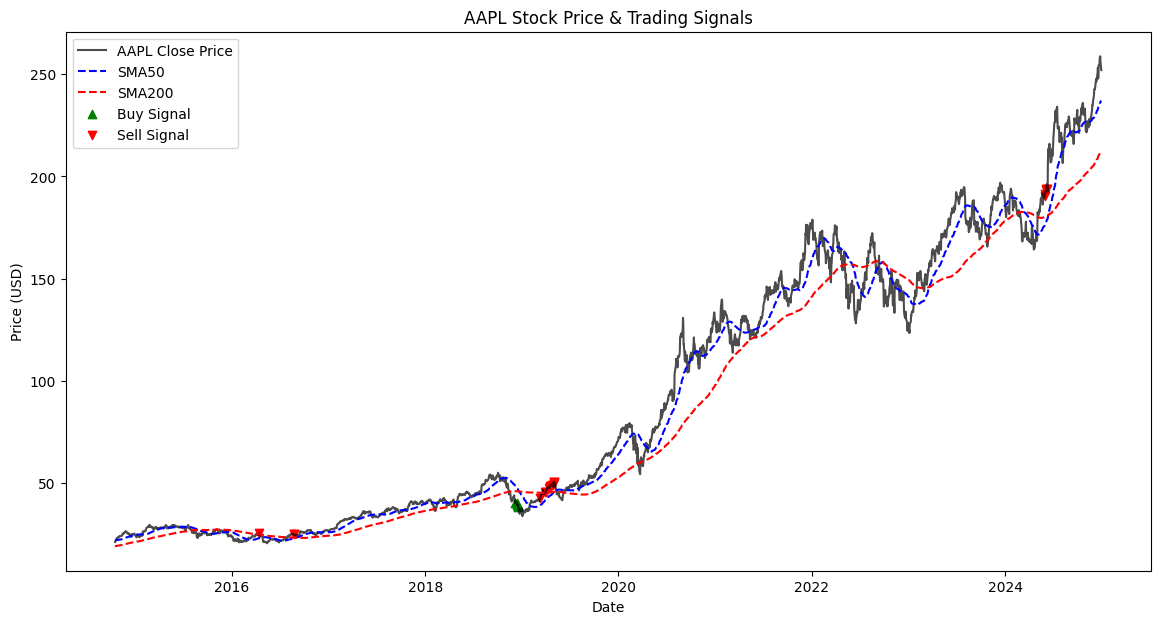

In [15]:
plt.figure(figsize=(14, 7))

# 주가 차트
plt.plot(df.index, df["Close"], label="AAPL Close Price", color="black", alpha=0.7)

# SMA 50 & SMA 200
plt.plot(df.index, df["SMA50"], label="SMA50", color="blue", linestyle="dashed")
plt.plot(df.index, df["SMA200"], label="SMA200", color="red", linestyle="dashed")

# 매수·매도 신호 표시
plt.scatter(df[df["Buy_Signal"]].index, df[df["Buy_Signal"]]["Close"], marker="^", color="green", label="Buy Signal", alpha=1)
plt.scatter(df[df["Sell_Signal"]].index, df[df["Sell_Signal"]]["Close"], marker="v", color="red", label="Sell Signal", alpha=1)

plt.title("AAPL Stock Price & Trading Signals")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [16]:
success_count = 0
total_trades = df["Buy_Signal"].sum()

for date in buy_dates:
    try:
        future_price = df.loc[date + pd.Timedelta(days=10), "Close"]
        buy_price = df.loc[date, "Close"]
        if future_price > buy_price:
            success_count += 1
    except KeyError:
        continue  # 날짜 초과 시 예외 처리

success_rate = (success_count / total_trades) * 100
print(f"✅ 매수 신호 후 10일 내 상승 확률: {success_rate:.2f}%")

✅ 매수 신호 후 10일 내 상승 확률: 0.00%


In [17]:
success_count = 0
total_trades = df["Sell_Signal"].sum()

for date in sell_dates:
    try:
        future_price = df.loc[date + pd.Timedelta(days=10), "Close"]
        sell_price = df.loc[date, "Close"]
        if future_price < sell_price:
            success_count += 1
    except KeyError:
        continue  # 날짜 초과 시 예외 처리

success_rate = (success_count / total_trades) * 100
print(f"❌ 매도 신호 후 10일 내 하락 확률: {success_rate:.2f}%")

❌ 매도 신호 후 10일 내 하락 확률: 21.05%


In [18]:
import pandas as pd
import pandas_datareader.data as web
import datetime
import ta
import matplotlib.pyplot as plt

# 데이터 불러오기
ticker = "AAPL"
df = yf.download(ticker, start="2014-01-01", end="2024-12-31")

# 지표 계산
df['MACD'] = ta.trend.macd(df['Close'])
df['MACD_signal'] = ta.trend.macd_signal(df['Close'])
df['RSI'] = ta.momentum.rsi(df['Close'])
df['ATR'] = ta.volatility.average_true_range(df['High'], df['Low'], df['Close'])
df['MFI'] = ta.volume.money_flow_index(df['High'], df['Low'], df['Close'], df['Volume'])

# 거래 시그널
df['Signal'] = 0
df.loc[
    (df['MACD'] > df['MACD_signal']) &
    (df['RSI'] > 30) & (df['RSI'] < 70) &
    (df['MFI'] > 50) &
    (df['ATR'] > df['ATR'].rolling(window=14).mean()),
    'Signal'
] = 1

# 백테스트
df['Position'] = df['Signal'].shift(1)
df['Daily Return'] = df['Close'].pct_change()
df['Strategy Return'] = df['Daily Return'] * df['Position']

# 누적 수익률
(1 + df[['Daily Return', 'Strategy Return']]).cumprod().plot(figsize=(14, 7))
plt.title('Strategy Backtest: MACD + RSI + ATR + MFI')
plt.show()


[*********************100%***********************]  1 of 1 completed


ValueError: Data must be 1-dimensional, got ndarray of shape (2767, 1) instead